# Equation solving
The topic of this notebook are algebric equations and how to solve them. The examples in this notebook follow those from chapter 5 of the book by Johansson [*Numerical Python, 3rd Edition*](https://github.com/jrjohansson/numerical-python-book-code/blob/master/ch05-code-listing.ipynb). 

In [1]:
import numpy as np
import sympy
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
print('NumPy version: {}'.format(np.__version__))
print('SymPy version: {}'.format(sympy.__version__))
print('SciPy version: {}'.format(scipy.__version__))
print('Matplotlib version: {}'.format(mpl.__version__))

NumPy version: 1.26.4
SymPy version: 1.14.0
SciPy version: 1.17.1
Matplotlib version: 3.8.4


## Linear equations
We start with linear equations of the type
$$\hat{A} x=b$$
where $\hat{A}$ is a $n \times n$ matrix, $x$ is a vector of variables and $b$ is a constant vector. Many systems can be described as linear in physics and other science fields. When a system is not linear it can be linearized around a point. The goal in these problems is to calculate
$$x=\hat{A}^{-1}b$$
In order to solve a system of linear equations of n variables we need n equations. This means that $\hat{A}$ is a square matrix.

We define two linear equations 
$$
    \begin{matrix}
        2x_1 + 3x_2 = 4  \\
        5x_1 + 4x_2 = 3   \\
    \end{matrix}
$$
and compute their values so that we can plot them

In [7]:
x1 = np.linspace(-4, 2, 100)
x2_1 = (4 - 2 * x1)/3
x2_2 = (3 - 5 * x1)/4

We solve the linear system numerically using the [SciPy's linear algebra](https://docs.scipy.org/doc/scipy/reference/linalg.html) module 

In [3]:
from scipy import linalg as la
A = np.array([[2, 3], [5, 4]])
b = np.array([4, 3])
x = la.solve(A, b)
x

array([-1.,  2.])

We plot the two linear equations and the point of intersection that is the (unique) solution of the linear system 

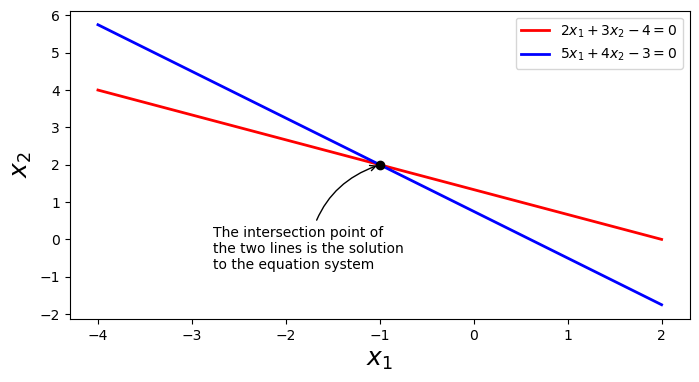

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(x1, x2_1, 'r', lw=2, label=r"$2x_1+3x_2-4=0$")
ax.plot(x1, x2_2, 'b', lw=2, label=r"$5x_1+4x_2-3=0$")
ax.plot(x[0], x[1], 'ko', lw=2)
ax.annotate("The intersection point of\nthe two lines is the solution\nto the equation system",
            xy=(x[0], x[1]), xycoords='data',
            xytext=(-120, -75), textcoords='offset points', 
            arrowprops=dict(arrowstyle="->", connectionstyle="arc3, rad=-.3"))

ax.set_xlabel(r"$x_1$", fontsize=18)
ax.set_ylabel(r"$x_2$", fontsize=18)
ax.legend();

We can solve the linear system using symbolic calculations implemented in the [SymPy linear algebra](https://docs.sympy.org/latest/modules/matrices/matrices.html#linear-algebra) module. The algorithm used is [Gaussian elimination] or [LU decomposition](https://en.wikipedia.org/wiki/LU_decomposition). 

In [12]:
A = sympy.Matrix([[2, 3], [5, 4]])
b = sympy.Matrix([4, 3])

In order to have one unique soulution, a system of two equations in two variables must have rank 2

In [13]:
A.rank()

2

### Condition number
One important property of a linear system is its [condition number](https://en.wikipedia.org/wiki/Condition_number). It represents how a little change in the variable $x$ affects the output variable $b$
$$\hat{A} \delta x=\delta b$$
The condition number provides an estimate of the accuracy of the solution. The closer the contion number to 1, the better. 

In [14]:
A.condition_number()

sqrt(2*sqrt(170) + 27)/sqrt(27 - 2*sqrt(170))

In [15]:
x = A.solve(b)
x

Matrix([
[-1],
[ 2]])

## Least squares method
Usually we collect many observations to represent the relationship between one or more independent variables and one dependent variable. These observations are used to find a function that fits the data. One such function can be defined using polynomials.
$$y=a_0 + a_1 x + a_2 x^2+...+a_n x^n$$
This equation is linear in the parameters $a_i$ that are unknown and can be found using the least squares methods. For instance we create some noisy data points around a polynomial function. We use the least squares method to fit the data points so that we will be able to compare the found parameters with the true ones. 

In [11]:
np.random.seed(1234)

# define true model parameters
x = np.linspace(-1, 1, 100)
a, b, c = 1, 2, 3
y_exact = a + b * x + c * x**2

# simulate noisy (X,Y) data points
m = 100
X = 1 - 2 * np.random.rand(m)
Y = a + b * X + c * X**2 + np.random.randn(m)

We build a $m \times 3$ matrix of $X^0, X^1,X^2$ values. Each triple represents an instance of the linear equation 
$$y=a_0x^0 + a_1 x^1 + a_2 x^2$$
With this approach we can use the lstq() method of the SciPy linear algebra module to solve the **overdetermined** problem to calculate the three unknown parameters $a_i$

In [17]:
# fit the data to the model using linear least square
A = np.vstack([X**0, X**1, X**2])  # see np.vander for alternative
sol, r, rank, sv = la.lstsq(A.T, Y)
y_fit = sol[0] + sol[1] * x + sol[2] * x**2

In [18]:
A.shape

(3, 100)

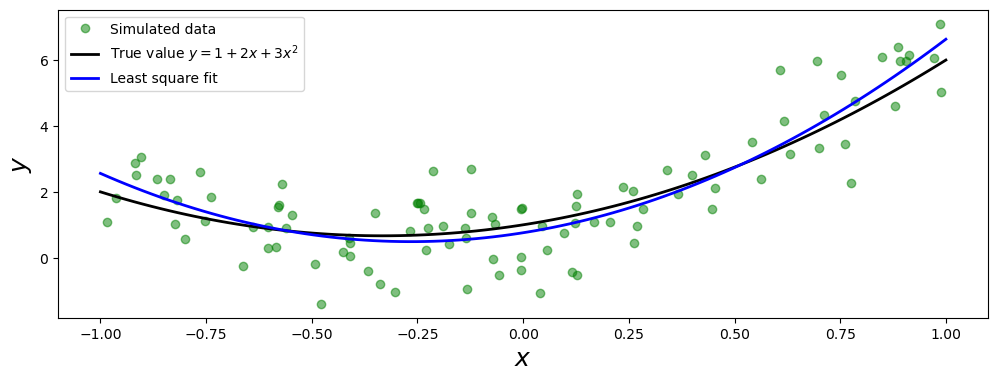

In [19]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(X, Y, 'go', alpha=0.5, label='Simulated data')
ax.plot(x, y_exact, 'k', lw=2, label='True value $y = 1 + 2x + 3x^2$')
ax.plot(x, y_fit, 'b', lw=2, label='Least square fit')
ax.set_xlabel(r"$x$", fontsize=18)
ax.set_ylabel(r"$y$", fontsize=18)
ax.legend(loc=2);